# `fact_indicator_value`: подробный EDA и очистка данных

Этот notebook посвящён одной из самых важных таблиц проекта — `fact_indicator_value`.

Именно здесь хранятся **численные значения индикаторов по странам и годам**.  
Если `dim_indicator` объясняет, **что означает код индикатора**, то `fact_indicator_value` отвечает на вопрос:

> **какое значение у этого индикатора было в конкретной стране в конкретный год?**

Это уже не просто справочник, а основная аналитическая факт-таблица.

---

## Почему эта таблица критически важна

`fact_indicator_value` — это один из основных data layers, потому что она позволяет:

1. анализировать динамику демографических и socioeconomic indicators по времени;
2. сравнивать страны между собой;
3. строить country profiles;
4. делать meaningful storytelling на фронте;
5. подготавливать clean analytical mart уровня `country-year`.

---

## Что мы будем делать

1. Загрузим `fact_indicator_value` и dimension tables  
2. Разберём смысл колонок  
3. Посмотрим на структуру и типы  
4. Проверим пропуски  
5. Проверим ключевые поля  
6. Проверим связь с `dim_country`  
7. Проверим связь с `dim_indicator`  
8. Проверим дубликаты и конфликтующие дубликаты  
9. Проанализируем coverage по:
   - годам
   - странам
   - индикаторам
   - источникам  
10. Посмотрим на selected indicators  
11. Построим качественные графики  
12. Подготовим `fact_indicator_value_clean`  
13. Подготовим wide table для следующих этапов проекта

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)

DATA_DIR = Path("./data_exports")
OUTPUT_DIR = Path("./notebooks/eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

Используем:
- `fact_indicator_value.csv`
- `dim_country_clean.csv` или `dim_country_enriched.csv`, если они уже существуют
- `dim_indicator_clean.csv` или `dim_indicator_enriched.csv`, если они уже существуют

Так notebook становится совместимым с уже проделанной работой по dimension tables.

In [2]:
fact = pd.read_csv(DATA_DIR / "fact_indicator_value.csv")

country_enriched_path = OUTPUT_DIR / "dim_country_enriched.csv"
country_clean_path = OUTPUT_DIR / "dim_country_clean.csv"
indicator_enriched_path = OUTPUT_DIR / "dim_indicator_enriched.csv"
indicator_clean_path = OUTPUT_DIR / "dim_indicator_clean.csv"

if country_enriched_path.exists():
    dim_country = pd.read_csv(country_enriched_path)
elif country_clean_path.exists():
    dim_country = pd.read_csv(country_clean_path)
else:
    dim_country = pd.read_csv(DATA_DIR / "dim_country.csv")

if indicator_enriched_path.exists():
    dim_indicator = pd.read_csv(indicator_enriched_path)
elif indicator_clean_path.exists():
    dim_indicator = pd.read_csv(indicator_clean_path)
else:
    dim_indicator = pd.read_csv(DATA_DIR / "dim_indicator.csv")

print("fact_indicator_value:", fact.shape)
print("dim_country:", dim_country.shape)
print("dim_indicator:", dim_indicator.shape)

fact_indicator_value: (260770, 5)
dim_country: (217, 5)
dim_indicator: (17, 6)


## 2. Что означают колонки таблицы

Обычно в `fact_indicator_value` у вас есть такие колонки:

- `country_iso3`
- `year`
- `source`
- `indicator_code`
- `value`

### `country_iso3`
Код страны.

### `year`
Год наблюдения.

### `source`
Источник индикатора:
- `un`
- `worldbank`

### `indicator_code`
Код индикатора.

### `value`
Численное значение индикатора.

---

### Гранулярность таблицы

Естественная логика такая:

**одна строка = один индикатор × одна страна × один год × один источник**

То есть естественный ключ в идеале выглядит так:

- `country_iso3`
- `year`
- `source`
- `indicator_code`

Именно это мы потом будем проверять.

## 3. Первичный обзор таблицы

In [3]:
fact.head(10)

,country_iso3,year,source,indicator_code,value
0,ALB,1987,un,UN_18,28.647
1,ALB,1988,un,UN_18,28.480
2,ALB,1989,un,UN_18,28.395
3,ALB,1990,un,UN_18,28.376
4,ALB,1991,un,UN_18,28.199
5,ALB,1992,un,UN_18,27.893
6,ALB,1993,un,UN_18,27.709
7,ALB,1994,un,UN_18,27.619
8,ALB,1995,un,UN_18,27.587
9,ALB,1996,un,UN_18,27.564


In [4]:
fact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260770 entries, 0 to 260769
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   country_iso3    260770 non-null  object 
 1   year            260770 non-null  int64  
 2   source          260770 non-null  object 
 3   indicator_code  260770 non-null  object 
 4   value           211800 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 9.9+ MB


На этом этапе мы проверяем:
- сколько строк в таблице;
- какие типы у колонок;
- как выглядят значения;
- нет ли очевидных structural problems.

## 4. Первичная нормализация

Перед нормальным EDA приводим данные в аккуратный вид:

- trim строк;
- `country_iso3` -> UPPER;
- `indicator_code` -> UPPER;
- `source` -> lower;
- `year` -> numeric;
- `value` -> numeric.

Это пока не финальная очистка, а техническая подготовка.

In [5]:
fact_work = fact.copy()

def clean_string_series(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
         .str.strip()
         .str.replace(r"\s+", " ", regex=True)
    )

fact_work["country_iso3"] = clean_string_series(fact_work["country_iso3"]).str.upper()
fact_work["source"] = clean_string_series(fact_work["source"]).str.lower()
fact_work["indicator_code"] = clean_string_series(fact_work["indicator_code"]).str.upper()

fact_work["year"] = pd.to_numeric(fact_work["year"], errors="coerce")
fact_work["value"] = pd.to_numeric(fact_work["value"], errors="coerce")

fact_work.head()

,country_iso3,year,source,indicator_code,value
0,ALB,1987,un,UN_18,28.647
1,ALB,1988,un,UN_18,28.480
2,ALB,1989,un,UN_18,28.395
3,ALB,1990,un,UN_18,28.376
4,ALB,1991,un,UN_18,28.199


## 5. Анализ пропусков

Смотрим долю пропусков по колонкам.

Это ключевой шаг, потому что нужно разделить:
- **структурные проблемы** — если пропуски в ключевых полях;
- **data coverage issues** — если пропуски в `value`.

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": fact_work.isna().sum(),
    "missing_ratio": fact_work.isna().mean()
}).sort_values("missing_ratio", ascending=False)

missing_summary

,missing_count,missing_ratio
value,48970,0.18779
country_iso3,0,0.00000
year,0,0.00000
source,0,0.00000
indicator_code,0,0.00000


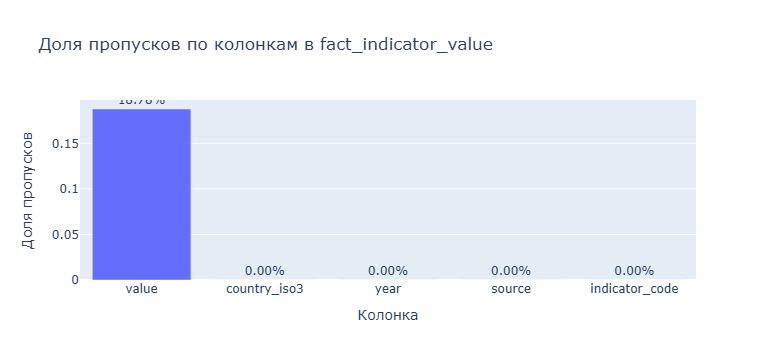

In [7]:
fig = px.bar(
    missing_summary.reset_index().rename(columns={"index": "column"}),
    x="column",
    y="missing_ratio",
    title="Доля пропусков по колонкам в fact_indicator_value",
    text="missing_ratio"
)
fig.update_traces(texttemplate="%{text:.2%}", textposition="outside")
fig.update_layout(xaxis_title="Колонка", yaxis_title="Доля пропусков")
fig.show()

### Как это интерпретировать

- пропуски в `country_iso3`, `year`, `source`, `indicator_code` — это structural issues;
- пропуски в `value` часто означают неполное покрытие и бывают вполне ожидаемыми.

То есть:
- missing in key fields = проблема схемы;
- missing in value = проблема coverage.

В нашем случае пропуски в value около 20%. по остальным показателям пропусков нет.

## 6. Проверка ключевых полей

Сейчас отдельно проверим ключевые колонки:
- `country_iso3`
- `year`
- `source`
- `indicator_code`

In [8]:
key_cols = ["country_iso3", "year", "source", "indicator_code"]

key_missing_summary = pd.DataFrame({
    "missing_count": fact_work[key_cols].isna().sum(),
    "missing_ratio": fact_work[key_cols].isna().mean()
})

key_missing_summary

,missing_count,missing_ratio
country_iso3,0,0.0
year,0,0.0
source,0,0.0
indicator_code,0,0.0


Все чисто

## 7. Анализ источников

Теперь посмотрим, как распределяются строки по `source`.

In [9]:
source_counts = (
    fact_work["source"]
    .value_counts(dropna=False)
    .rename_axis("source")
    .reset_index(name="n_rows")
)

source_counts

,source,n_rows
0,worldbank,135720
1,un,125050


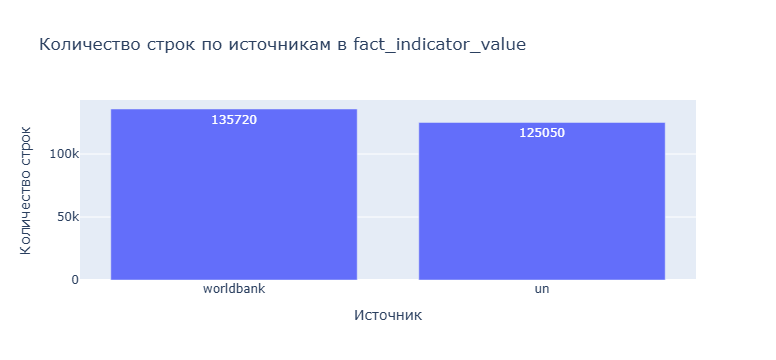

In [10]:
fig = px.bar(
    source_counts,
    x="source",
    y="n_rows",
    title="Количество строк по источникам в fact_indicator_value",
    text="n_rows"
)
fig.update_layout(xaxis_title="Источник", yaxis_title="Количество строк")
fig.show()

Доли UN / World Bank примерно одинаковые

## 8. Анализ годов

Посмотрим:
- минимальный и максимальный год;
- распределение количества строк по времени;
- отдельно по источникам.

In [11]:
fact_work["year"].describe()

count    260770.000000
mean       1995.836331
std          18.650303
min        1960.000000
25%        1980.000000
50%        1996.000000
75%        2012.000000
max        2030.000000
Name: year, dtype: float64

In [12]:
rows_by_year = (
    fact_work.dropna(subset=["year"])
    .groupby("year")
    .size()
    .reset_index(name="n_rows")
)

rows_by_year.head()

,year,n_rows
0,1960,2088
1,1961,2088
2,1962,2088
3,1963,2088
4,1964,2088


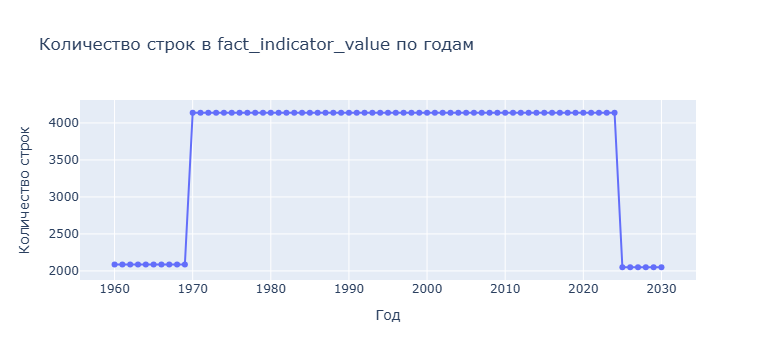

In [13]:
fig = px.line(
    rows_by_year,
    x="year",
    y="n_rows",
    markers=True,
    title="Количество строк в fact_indicator_value по годам"
)
fig.update_layout(xaxis_title="Год", yaxis_title="Количество строк")
fig.show()

Можно увидеть что до 1970 годов данных достаточно мало, что сужает анализ. После 2024 года идет предсказание числовых показателей, а не действительные значения

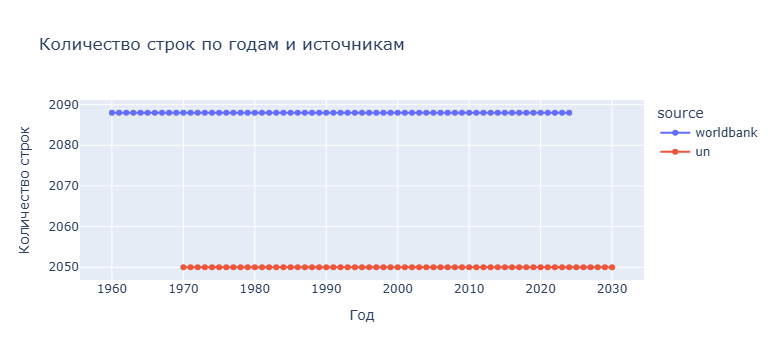

In [14]:
rows_by_year_source = (
    fact_work.dropna(subset=["year", "source"])
    .groupby(["year", "source"])
    .size()
    .reset_index(name="n_rows")
)

fig = px.line(
    rows_by_year_source,
    x="year",
    y="n_rows",
    color="source",
    markers=True,
    title="Количество строк по годам и источникам"
)
fig.update_layout(xaxis_title="Год", yaxis_title="Количество строк")
fig.show()

Видно небольшую разницу ~40 строк

## 9. Проверка связи с `dim_country`

Теперь смотрим, все ли `country_iso3` из факт-таблицы матчятся в dimension table стран.

In [15]:
dim_country_work = dim_country.copy()

if "iso3" in dim_country_work.columns:
    dim_country_work["iso3"] = clean_string_series(dim_country_work["iso3"]).str.upper()

# 1. Проверяем качество самой dim_country
dim_country_missing_iso3 = dim_country_work[dim_country_work["iso3"].isna()].copy()

print("Всего строк в dim_country:", len(dim_country_work))
print("Строк в dim_country без iso3:", len(dim_country_missing_iso3))

if len(dim_country_missing_iso3) > 0:
    display(dim_country_missing_iso3)

# valid iso3 from dim_country
valid_country_iso3 = set(dim_country_work["iso3"].dropna().unique())

print("Количество валидных iso3 в dim_country:", len(valid_country_iso3))

# 2. Смотрим country codes в fact
fact_country_codes = sorted(fact_work["country_iso3"].dropna().unique())
fact_country_codes_set = set(fact_country_codes)

print("Количество уникальных country_iso3 в fact:", len(fact_country_codes))

# 3. Какие коды есть в fact, но нет в dim_country
unmatched_country_codes = sorted(fact_country_codes_set - valid_country_iso3)

print("Количество unmatched country_iso3:", len(unmatched_country_codes))
print("Unmatched country_iso3:")
print(unmatched_country_codes[:100])

# 4. Какие страны из dim_country вообще представлены в fact
matched_country_codes = sorted(fact_country_codes_set & valid_country_iso3)

country_coverage_ratio = len(matched_country_codes) / len(valid_country_iso3) if len(valid_country_iso3) > 0 else np.nan

print("Количество стран из dim_country, которые есть в fact:", len(matched_country_codes))
print(f"Покрытие списка dim_country в fact: {country_coverage_ratio:.2%}")

# 5. Какие страны из dim_country вообще НЕ покрыты fact-таблицей
missing_from_fact_codes = sorted(valid_country_iso3 - fact_country_codes_set)

print("Количество стран из dim_country, которых нет в fact:", len(missing_from_fact_codes))
print("Примеры стран из dim_country, которых нет в fact:")
print(missing_from_fact_codes[:100])

missing_from_fact_df = dim_country_work[dim_country_work["iso3"].isin(missing_from_fact_codes)].copy()
missing_from_fact_df = missing_from_fact_df.sort_values("iso3")

# 6. Чистим fact: удаляем unmatched country codes
fact_country_only = fact_work[fact_work["country_iso3"].isin(valid_country_iso3)].copy()

print("Исходный размер fact:", fact_work.shape)
print("Размер fact после удаления unmatched country_iso3:", fact_country_only.shape)

Всего строк в dim_country: 217
Строк в dim_country без iso3: 0
Количество валидных iso3 в dim_country: 217
Количество уникальных country_iso3 в fact: 281
Количество unmatched country_iso3: 64
Unmatched country_iso3:
['AFE', 'AFW', 'AIA', 'ARB', 'BES', 'BLM', 'CEB', 'COK', 'CSS', 'EAP', 'EAR', 'EAS', 'ECA', 'ECS', 'EMU', 'ESH', 'EUU', 'FCS', 'FLK', 'GGY', 'GLP', 'GUF', 'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'JEY', 'LAC', 'LCN', 'LDC', 'LMY', 'LTE', 'MEA', 'MIC', 'MNA', 'MSR', 'MTQ', 'MYT', 'NAC', 'NIU', 'OED', 'OSS', 'PRE', 'PSS', 'PST', 'REU', 'SAS', 'SHN', 'SPM', 'SSA', 'SSF', 'SST', 'TEA', 'TEC', 'TKL', 'TLA', 'TMN', 'TSA', 'TSS', 'TWN', 'WLD', 'WLF']
Количество стран из dim_country, которые есть в fact: 217
Покрытие списка dim_country в fact: 100.00%
Количество стран из dim_country, которых нет в fact: 0
Примеры стран из dim_country, которых нет в fact:
[]
Исходный размер fact: (260770, 5)
Размер fact после удаления unmatched country_iso3: (228496, 5)


Удалили все unmathed iso3 из fact_indicator_value, так как dim_country уже покрывает почти все страны

In [16]:
unmatched_country_df = pd.DataFrame({"country_iso3": unmatched_country_codes})
unmatched_country_df.head(10)

,country_iso3
0,AFE
1,AFW
2,AIA
3,ARB
4,BES
5,BLM
6,CEB
7,COK
8,CSS
9,EAP


## 10. Проверка связи с `dim_indicator`

Теперь проверим, все ли indicator codes из fact-таблицы описаны в `dim_indicator`.

In [17]:
dim_indicator_work = dim_indicator.copy()

if "source" in dim_indicator_work.columns:
    dim_indicator_work["source"] = clean_string_series(dim_indicator_work["source"]).str.lower()
if "code" in dim_indicator_work.columns:
    dim_indicator_work["code"] = clean_string_series(dim_indicator_work["code"]).str.upper()

valid_indicator_pairs = set(
    zip(
        dim_indicator_work["source"].dropna(),
        dim_indicator_work["code"].dropna()
    )
)

fact_indicator_pairs = set(
    zip(
        fact_work["source"].dropna(),
        fact_work["indicator_code"].dropna()
    )
)

unmatched_indicator_pairs = sorted(fact_indicator_pairs - valid_indicator_pairs)

print("Количество уникальных (source, indicator_code) в fact:", len(fact_indicator_pairs))
print("Количество unmatched (source, indicator_code):", len(unmatched_indicator_pairs))
unmatched_indicator_pairs[:50]

Количество уникальных (source, indicator_code) в fact: 17
Количество unmatched (source, indicator_code): 0


[]

In [18]:
pd.DataFrame(unmatched_indicator_pairs, columns=["source", "indicator_code"]).head(50)

,source,indicator_code


Все сходится

## 11. Проверка дубликатов

Для этой таблицы естественный ключ:

- `country_iso3`
- `year`
- `source`
- `indicator_code`

Сейчас проверим:
- exact duplicates;
- duplicate groups;
- conflicting duplicates.

In [19]:
fact_key = ["country_iso3", "year", "source", "indicator_code"]

dup_groups = (
    fact_work.dropna(subset=fact_key)
    .groupby(fact_key, dropna=False)
    .agg(
        n_rows=("value", "size"),
        n_unique_values=("value", pd.Series.nunique)
    )
    .reset_index()
)

duplicate_groups = dup_groups[dup_groups["n_rows"] > 1].copy()
conflicting_duplicate_groups = dup_groups[
    (dup_groups["n_rows"] > 1) & (dup_groups["n_unique_values"] > 1)
].copy()

print("Групп с дубликатами:", len(duplicate_groups))
print("Групп с конфликтующими значениями:", len(conflicting_duplicate_groups))

Групп с дубликатами: 0
Групп с конфликтующими значениями: 0


In [20]:
duplicate_groups.head(20)

,country_iso3,year,source,indicator_code,n_rows,n_unique_values


In [21]:
conflicting_duplicate_groups.head(20)

,country_iso3,year,source,indicator_code,n_rows,n_unique_values


### Почему это важно

- точные дубли можно убрать;
- conflicting duplicates нельзя игнорировать, потому что один и тот же indicator для одной страны и года не должен иметь несколько разных значений.

Дублей не обнаружено

## 12. Coverage по индикаторам

Посмотрим:
- сколько строк приходится на каждый `(source, indicator_code)`;
- сколько стран покрывает каждый indicator;
- сколько лет покрывает каждый indicator;
- сколько непустых значений у него есть.

In [22]:
indicator_coverage = (
    fact_work.dropna(subset=["source", "indicator_code"])
    .groupby(["source", "indicator_code"])
    .agg(
        n_rows=("value", "size"),
        n_non_null_values=("value", lambda s: s.notna().sum()),
        n_countries=("country_iso3", "nunique"),
        n_years=("year", "nunique")
    )
    .reset_index()
    .sort_values("n_non_null_values", ascending=False)
)

indicator_coverage

,source,indicator_code,n_rows,n_non_null_values,n_countries,n_years
16,worldbank,SP.URB.TOTL.IN.ZS,16965,16965,261,65
14,worldbank,SP.ADO.TFRT,16965,16704,261,65
15,worldbank,SP.DYN.TFRT.IN,16965,16672,261,65
6,un,UN_67,14396,14396,236,61
7,un,UN_83,14396,14396,236,61
0,un,UN_18,14396,14396,236,61
5,un,UN_66,14396,14396,236,61
4,un,UN_50,14396,14396,236,61
3,un,UN_41,14396,14396,236,61
8,un,UN_86,14396,14396,236,61


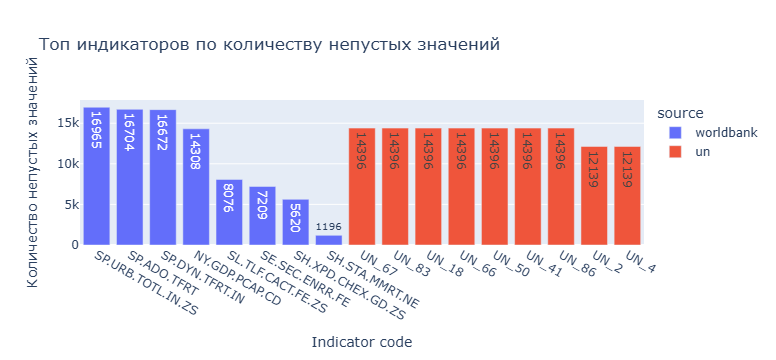

In [23]:
fig = px.bar(
    indicator_coverage.head(20),
    x="indicator_code",
    y="n_non_null_values",
    color="source",
    title="Топ индикаторов по количеству непустых значений",
    text="n_non_null_values"
)
fig.update_layout(xaxis_title="Indicator code", yaxis_title="Количество непустых значений")
fig.show()

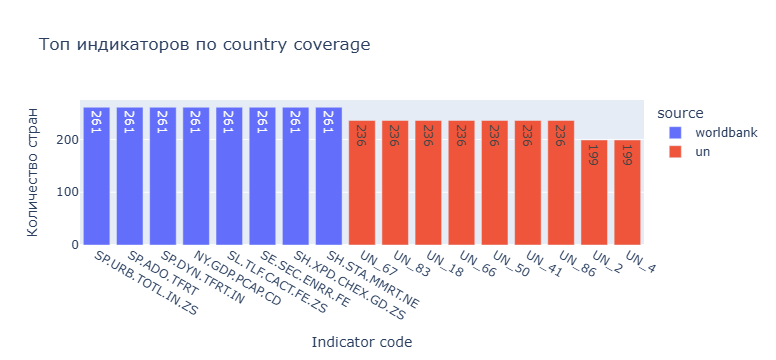

In [24]:
fig = px.bar(
    indicator_coverage.head(20),
    x="indicator_code",
    y="n_countries",
    color="source",
    title="Топ индикаторов по country coverage",
    text="n_countries"
)
fig.update_layout(xaxis_title="Indicator code", yaxis_title="Количество стран")
fig.show()

## 13. Выделение project-relevant indicators

Теперь зададим curated subset ваших индикаторов.

In [25]:
SELECTED_INDICATORS = {
    ("un", "UN_18"): "mean_age_childbearing",
    ("un", "UN_2"): "contraceptive_prevalence_modern",
    ("un", "UN_4"): "unmet_need_family_planning",
    ("un", "UN_41"): "female_population_15_49",
    ("un", "UN_50"): "population_change",
    ("un", "UN_66"): "crude_net_migration_rate",
    ("un", "UN_67"): "median_age",
    ("un", "UN_83"): "child_dependency_ratio",
    ("un", "UN_86"): "total_dependency_ratio",
    ("worldbank", "NY.GDP.PCAP.CD"): "gdp_per_capita",
    ("worldbank", "SE.SEC.ENRR.FE"): "female_secondary_enrollment",
    ("worldbank", "SH.STA.MMRT.NE"): "maternal_mortality",
    ("worldbank", "SH.XPD.CHEX.GD.ZS"): "health_expenditure_pct_gdp",
    ("worldbank", "SL.TLF.CACT.FE.ZS"): "female_labor_force_participation",
    ("worldbank", "SP.ADO.TFRT"): "adolescent_fertility",
    ("worldbank", "SP.DYN.TFRT.IN"): "tfr",
    ("worldbank", "SP.URB.TOTL.IN.ZS"): "urban_population_pct",
}

selected_fact = fact_work[
    fact_work.apply(lambda r: (r["source"], r["indicator_code"]) in SELECTED_INDICATORS, axis=1)
].copy()

selected_fact["indicator_short"] = selected_fact.apply(
    lambda r: SELECTED_INDICATORS.get((r["source"], r["indicator_code"])),
    axis=1
)

selected_fact.head()

,country_iso3,year,source,indicator_code,value,indicator_short
0,ALB,1987,un,UN_18,28.647,mean_age_childbearing
1,ALB,1988,un,UN_18,28.480,mean_age_childbearing
2,ALB,1989,un,UN_18,28.395,mean_age_childbearing
3,ALB,1990,un,UN_18,28.376,mean_age_childbearing
4,ALB,1991,un,UN_18,28.199,mean_age_childbearing


In [26]:
selected_indicator_coverage = (
    selected_fact.groupby(["source", "indicator_code", "indicator_short"])
    .agg(
        n_rows=("value", "size"),
        n_non_null_values=("value", lambda s: s.notna().sum()),
        n_countries=("country_iso3", "nunique"),
        n_years=("year", "nunique")
    )
    .reset_index()
    .sort_values("n_non_null_values", ascending=False)
)

selected_indicator_coverage

,source,indicator_code,indicator_short,n_rows,n_non_null_values,n_countries,n_years
16,worldbank,SP.URB.TOTL.IN.ZS,urban_population_pct,16965,16965,261,65
14,worldbank,SP.ADO.TFRT,adolescent_fertility,16965,16704,261,65
15,worldbank,SP.DYN.TFRT.IN,tfr,16965,16672,261,65
6,un,UN_67,median_age,14396,14396,236,61
7,un,UN_83,child_dependency_ratio,14396,14396,236,61
0,un,UN_18,mean_age_childbearing,14396,14396,236,61
5,un,UN_66,crude_net_migration_rate,14396,14396,236,61
4,un,UN_50,population_change,14396,14396,236,61
3,un,UN_41,female_population_15_49,14396,14396,236,61
8,un,UN_86,total_dependency_ratio,14396,14396,236,61


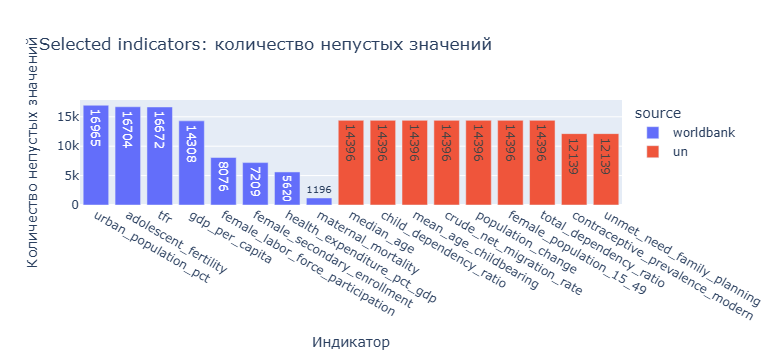

In [27]:
fig = px.bar(
    selected_indicator_coverage,
    x="indicator_short",
    y="n_non_null_values",
    color="source",
    title="         Selected indicators: количество непустых значений",
    text="n_non_null_values"
)
fig.update_layout(xaxis_title="Индикатор", yaxis_title="Количество непустых значений")
fig.show()

## 14. Heatmap: coverage по годам и выбранным индикаторам

Построим heatmap, чтобы увидеть:
- где coverage сильный,
- где данные редкие,
- какие индикаторы лучше подходят для long-run analysis.

То есть он показывает сколько непустых наблюдений есть по каждому индикатору в каждый год

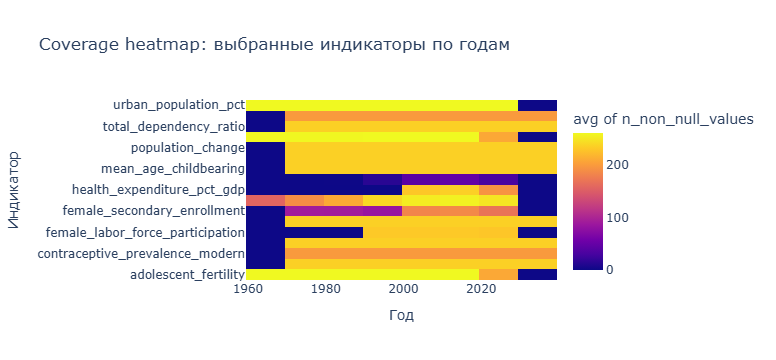

In [28]:
selected_year_indicator = (
    selected_fact.dropna(subset=["year"])
    .groupby(["indicator_short", "year"])
    .agg(n_non_null_values=("value", lambda s: s.notna().sum()))
    .reset_index()
)

fig = px.density_heatmap(
    selected_year_indicator,
    x="year",
    y="indicator_short",
    z="n_non_null_values",
    histfunc="avg",
    title="Coverage heatmap: выбранные индикаторы по годам"
)
fig.update_layout(xaxis_title="Год", yaxis_title="Индикатор")
fig.show()

## 15. Country-only filtering

Теперь делаем один из главных шагов очистки:
оставляем только строки, у которых `country_iso3` матчится в `dim_country`.

In [29]:
fact_country_only = fact_work[fact_work["country_iso3"].isin(valid_country_iso3)].copy()

print("Исходный размер fact:", fact_work.shape)
print("После фильтрации только по странам:", fact_country_only.shape)

Исходный размер fact: (260770, 5)
После фильтрации только по странам: (228496, 5)


Это превращает таблицу из смешанной сущности в более чистый country-level data layer.

## 16. Clean project subset

Теперь собираем более строгий clean analytical subset.
На этом этапе мы не просто оставляем selected indicators, а дополнительно ужесточаем правила отбора:

- сохраняем только реальные страны;
- оставляем только строки с валидными ключевыми полями;
- ограничиваем временное окно периодом 1970–2024;
- исключаем maternal_mortality, потому что у этого показателя слабое покрытие и он ухудшает качество итогового analytical subset.

In [30]:
# 1. Начинаем с country-level fact table
fact_project = fact_country_only.copy()

# 2. Оставляем только строки с валидными ключевыми полями
fact_project = fact_project.dropna(
    subset=["country_iso3", "year", "source", "indicator_code"]
).copy()

# 3. Тип года
fact_project["year"] = fact_project["year"].astype(int)

# 4. Ограничиваем годы
fact_project = fact_project[
    fact_project["year"].between(1970, 2024)
].copy()

# 5. Убираем maternal mortality из словаря выбранных индикаторов
SELECTED_INDICATORS_CLEAN = {
    k: v
    for k, v in SELECTED_INDICATORS.items()
    if v != "maternal_mortality"
}

# 6. Собираем ключ индикатора
fact_project["indicator_key"] = list(zip(fact_project["source"], fact_project["indicator_code"]))

# 7. Оставляем только нужные индикаторы
fact_project = fact_project[
    fact_project["indicator_key"].isin(SELECTED_INDICATORS_CLEAN.keys())
].copy()

# 8. Короткое имя индикатора
fact_project["indicator_short"] = fact_project["indicator_key"].map(SELECTED_INDICATORS_CLEAN)

# 9. Убираем технический столбец
fact_project = fact_project.drop(columns=["indicator_key"])

print("fact_project:", fact_project.shape)
print("Минимальный год:", fact_project["year"].min())
print("Максимальный год:", fact_project["year"].max())
print("\nИндикаторы в clean subset:")
print(sorted(fact_project["indicator_short"].dropna().unique()))

fact_project.head()

fact_project: (187825, 6)
Минимальный год: 1970
Максимальный год: 2024

Индикаторы в clean subset:
['adolescent_fertility', 'child_dependency_ratio', 'contraceptive_prevalence_modern', 'crude_net_migration_rate', 'female_labor_force_participation', 'female_population_15_49', 'female_secondary_enrollment', 'gdp_per_capita', 'health_expenditure_pct_gdp', 'mean_age_childbearing', 'median_age', 'population_change', 'tfr', 'total_dependency_ratio', 'unmet_need_family_planning', 'urban_population_pct']


,country_iso3,year,source,indicator_code,value,indicator_short
0,ALB,1987,un,UN_18,28.647,mean_age_childbearing
1,ALB,1988,un,UN_18,28.480,mean_age_childbearing
2,ALB,1989,un,UN_18,28.395,mean_age_childbearing
3,ALB,1990,un,UN_18,28.376,mean_age_childbearing
4,ALB,1991,un,UN_18,28.199,mean_age_childbearing


## 17. Повторная проверка дубликатов в clean subset

In [31]:
fact_project_key = ["country_iso3", "year", "source", "indicator_code"]

dup_groups_project = (
    fact_project.groupby(fact_project_key, dropna=False)
    .agg(
        n_rows=("value", "size"),
        n_unique_values=("value", pd.Series.nunique)
    )
    .reset_index()
)

duplicate_groups_project = dup_groups_project[dup_groups_project["n_rows"] > 1].copy()
conflicting_duplicate_groups_project = dup_groups_project[
    (dup_groups_project["n_rows"] > 1) & (dup_groups_project["n_unique_values"] > 1)
].copy()

print("В clean subset групп с дубликатами:", len(duplicate_groups_project))
print("В clean subset групп с конфликтами:", len(conflicting_duplicate_groups_project))

В clean subset групп с дубликатами: 0
В clean subset групп с конфликтами: 0


In [32]:
conflicting_duplicate_groups_project.head(20)

,country_iso3,year,source,indicator_code,n_rows,n_unique_values


## 18. Построение clean long table

In [33]:
fact_project_clean = fact_project.drop_duplicates(
    subset=["country_iso3", "year", "source", "indicator_code", "value"]
).copy()

fact_project_clean = (
    fact_project_clean.sort_values(["country_iso3", "source", "indicator_code", "year"])
    .groupby(["country_iso3", "year", "source", "indicator_code", "indicator_short"], as_index=False)
    .agg(value=("value", "first"))
)

print("fact_project_clean:", fact_project_clean.shape)
fact_project_clean.head(20)

fact_project_clean: (187825, 6)


,country_iso3,year,source,indicator_code,indicator_short,value
0,ABW,1970,un,UN_18,mean_age_childbearing,28.208000
1,ABW,1970,un,UN_41,female_population_15_49,14734.000000
2,ABW,1970,un,UN_50,population_change,-139.000000
3,ABW,1970,un,UN_66,crude_net_migration_rate,-20.169000
4,ABW,1970,un,UN_67,median_age,19.392686
5,ABW,1970,un,UN_83,child_dependency_ratio,65.259745
6,ABW,1970,un,UN_86,total_dependency_ratio,72.191147
7,ABW,1970,worldbank,NY.GDP.PCAP.CD,gdp_per_capita,NaN
8,ABW,1970,worldbank,SE.SEC.ENRR.FE,female_secondary_enrollment,NaN
9,ABW,1970,worldbank,SH.XPD.CHEX.GD.ZS,health_expenditure_pct_gdp,NaN


## 19. Построение wide table

Так как теперь indicator codes multi-source,  
именно `indicator_short` — лучший кандидат для колонок итоговой wide table.

In [34]:
indicator_country_year_wide = (
    fact_project_clean.pivot_table(
        index=["country_iso3", "year"],
        columns="indicator_short",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

indicator_country_year_wide.columns.name = None

print("indicator_country_year_wide:", indicator_country_year_wide.shape)
indicator_country_year_wide.head(20)

indicator_country_year_wide: (11935, 18)


,country_iso3,year,adolescent_fertility,child_dependency_ratio,contraceptive_prevalence_modern,crude_net_migration_rate,female_labor_force_participation,female_population_15_49,female_secondary_enrollment,gdp_per_capita,health_expenditure_pct_gdp,mean_age_childbearing,median_age,population_change,tfr,total_dependency_ratio,unmet_need_family_planning,urban_population_pct
0,ABW,1970,44.769,65.259745,NaN,-20.169,NaN,14734.0,NaN,NaN,NaN,28.208,19.392686,-139.0,2.973,72.191147,NaN,62.413451
1,ABW,1971,44.017,64.195784,NaN,-20.500,NaN,14828.5,NaN,NaN,NaN,28.111,19.522620,-201.0,2.862,71.509228,NaN,62.928418
2,ABW,1972,43.310,62.163019,NaN,-9.305,NaN,15079.0,NaN,NaN,NaN,28.020,19.761453,431.0,2.755,69.810858,NaN,63.436488
3,ABW,1973,43.140,59.350463,NaN,-5.182,NaN,15506.5,NaN,NaN,NaN,27.888,20.155941,649.0,2.655,67.268455,NaN,63.927938
4,ABW,1974,43.121,56.602765,NaN,-3.992,NaN,15975.5,NaN,NaN,NaN,27.766,20.583889,724.0,2.573,64.769722,NaN,64.393043
5,ABW,1975,43.221,53.974314,NaN,-4.719,NaN,16442.0,NaN,NaN,NaN,27.653,21.025908,657.0,2.499,62.370171,NaN,64.822080
6,ABW,1976,43.480,51.384246,NaN,-11.441,NaN,16849.5,NaN,NaN,NaN,27.548,21.580576,260.0,2.432,60.026640,NaN,65.205326
7,ABW,1977,43.848,48.992401,NaN,-11.835,NaN,17180.5,NaN,NaN,NaN,27.445,22.234863,220.0,2.372,57.906762,NaN,65.533055
8,ABW,1978,43.956,47.008742,NaN,-12.071,NaN,17450.5,NaN,NaN,NaN,27.347,22.885302,196.0,2.312,56.157729,NaN,65.795545
9,ABW,1979,44.113,45.378540,NaN,-12.246,NaN,17650.0,NaN,NaN,NaN,27.252,23.526232,158.0,2.257,54.705191,NaN,65.983072


## 20. Coverage summary для clean wide table

In [35]:
wide_indicator_cols = [c for c in indicator_country_year_wide.columns if c not in ["country_iso3", "year"]]

coverage_summary = pd.DataFrame({
    "column": wide_indicator_cols,
    "non_null_rows": [indicator_country_year_wide[c].notna().sum() for c in wide_indicator_cols],
    "coverage_ratio": [indicator_country_year_wide[c].notna().mean() for c in wide_indicator_cols]
}).sort_values("coverage_ratio", ascending=False)

coverage_summary

,column,non_null_rows,coverage_ratio
15,urban_population_pct,11935,1.000000
1,child_dependency_ratio,11880,0.995392
3,crude_net_migration_rate,11880,0.995392
5,female_population_15_49,11880,0.995392
9,mean_age_childbearing,11880,0.995392
10,median_age,11880,0.995392
11,population_change,11880,0.995392
13,total_dependency_ratio,11880,0.995392
0,adolescent_fertility,11718,0.981818
12,tfr,11698,0.980142


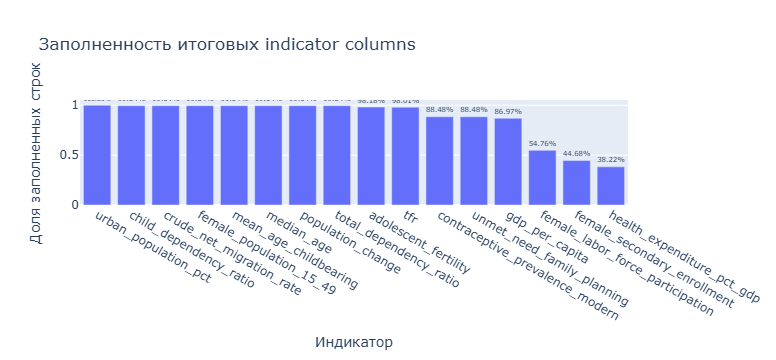

In [36]:
fig = px.bar(
    coverage_summary,
    x="column",
    y="coverage_ratio",
    title="Заполненность итоговых indicator columns",
    text="coverage_ratio"
)
fig.update_traces(texttemplate="%{text:.2%}", textposition="outside")
fig.update_layout(xaxis_title="Индикатор", yaxis_title="Доля заполненных строк")
fig.show()

## 21. Содержательные аналитические графики

In [37]:
country_lookup_cols = [c for c in ["iso3", "name", "region", "income_group"] if c in dim_country_work.columns]
country_lookup = dim_country_work[country_lookup_cols].drop_duplicates(subset=["iso3"]).copy()

indicator_enriched = indicator_country_year_wide.merge(
    country_lookup,
    left_on="country_iso3",
    right_on="iso3",
    how="left"
)

if "iso3" in indicator_enriched.columns:
    indicator_enriched = indicator_enriched.drop(columns=["iso3"])

indicator_enriched.head()

,country_iso3,year,adolescent_fertility,child_dependency_ratio,contraceptive_prevalence_modern,crude_net_migration_rate,female_labor_force_participation,female_population_15_49,female_secondary_enrollment,gdp_per_capita,health_expenditure_pct_gdp,mean_age_childbearing,median_age,population_change,tfr,total_dependency_ratio,unmet_need_family_planning,urban_population_pct,name,region,income_group
0,ABW,1970,44.769,65.259745,NaN,-20.169,NaN,14734.0,NaN,NaN,NaN,28.208,19.392686,-139.0,2.973,72.191147,NaN,62.413451,Aruba,Latin America & Caribbean,High income
1,ABW,1971,44.017,64.195784,NaN,-20.500,NaN,14828.5,NaN,NaN,NaN,28.111,19.522620,-201.0,2.862,71.509228,NaN,62.928418,Aruba,Latin America & Caribbean,High income
2,ABW,1972,43.310,62.163019,NaN,-9.305,NaN,15079.0,NaN,NaN,NaN,28.020,19.761453,431.0,2.755,69.810858,NaN,63.436488,Aruba,Latin America & Caribbean,High income
3,ABW,1973,43.140,59.350463,NaN,-5.182,NaN,15506.5,NaN,NaN,NaN,27.888,20.155941,649.0,2.655,67.268455,NaN,63.927938,Aruba,Latin America & Caribbean,High income
4,ABW,1974,43.121,56.602765,NaN,-3.992,NaN,15975.5,NaN,NaN,NaN,27.766,20.583889,724.0,2.573,64.769722,NaN,64.393043,Aruba,Latin America & Caribbean,High income


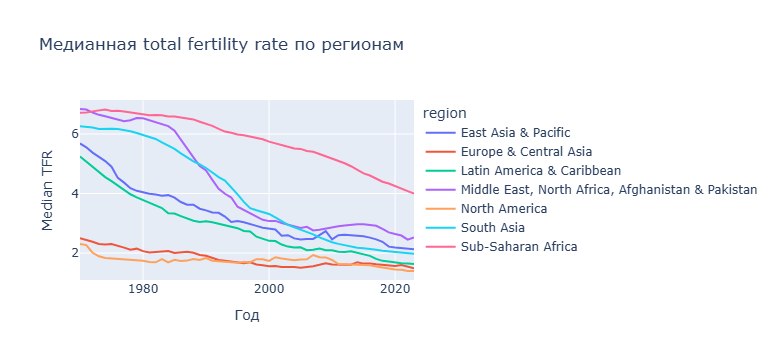

In [38]:
if "tfr" in indicator_enriched.columns and "region" in indicator_enriched.columns:
    regional_tfr = (
        indicator_enriched.dropna(subset=["region", "year", "tfr"])
        .groupby(["region", "year"], as_index=False)
        .agg(median_tfr=("tfr", "median"))
    )

    fig = px.line(
        regional_tfr,
        x="year",
        y="median_tfr",
        color="region",
        title="Медианная total fertility rate по регионам"
    )
    fig.update_layout(xaxis_title="Год", yaxis_title="Median TFR")
    fig.show()

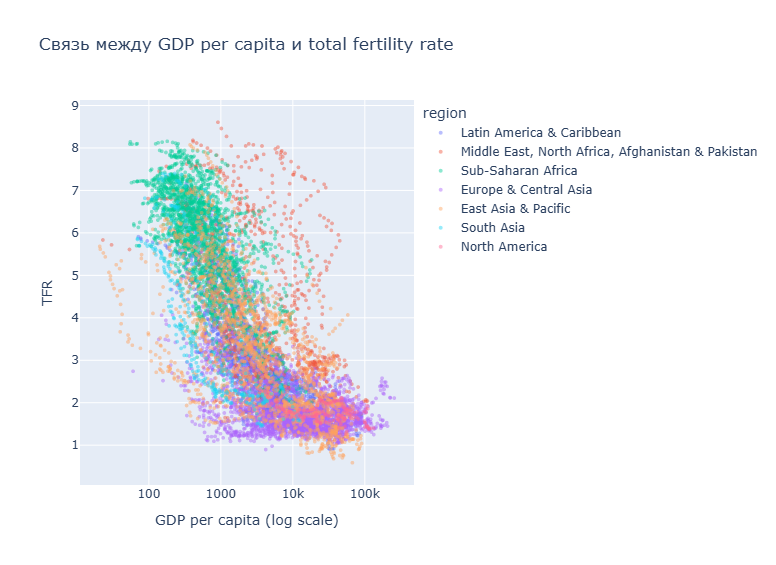

In [39]:
if {"gdp_per_capita", "tfr", "region"}.issubset(indicator_enriched.columns):
    scatter_df = indicator_enriched.dropna(subset=["gdp_per_capita", "tfr", "region"]).copy()

    fig = px.scatter(
        scatter_df,
        x="gdp_per_capita",
        y="tfr",
        color="region",
        hover_data=["country_iso3", "name", "year"] if "name" in scatter_df.columns else ["country_iso3", "year"],
        title="Связь между GDP per capita и total fertility rate",
        log_x=True
    )

    fig.update_traces(
        marker=dict(
            size=4,
            opacity=0.45,
            line=dict(width=0)
        )
    )

    fig.update_layout(
        xaxis_title="GDP per capita (log scale)",
        yaxis_title="TFR",
        width=1000,
        height=550
    )

    fig.show()

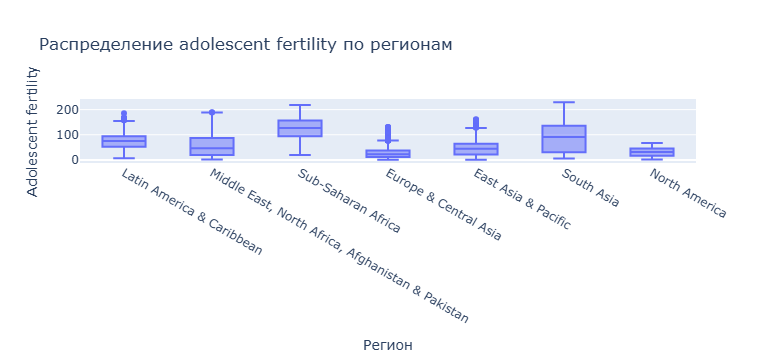

In [40]:
if "adolescent_fertility" in indicator_enriched.columns and "region" in indicator_enriched.columns:
    box_df = indicator_enriched.dropna(subset=["region", "adolescent_fertility"]).copy()

    fig = px.box(
        box_df,
        x="region",
        y="adolescent_fertility",
        title="Распределение adolescent fertility по регионам"
    )
    fig.update_layout(xaxis_title="Регион", yaxis_title="Adolescent fertility")
    fig.show()

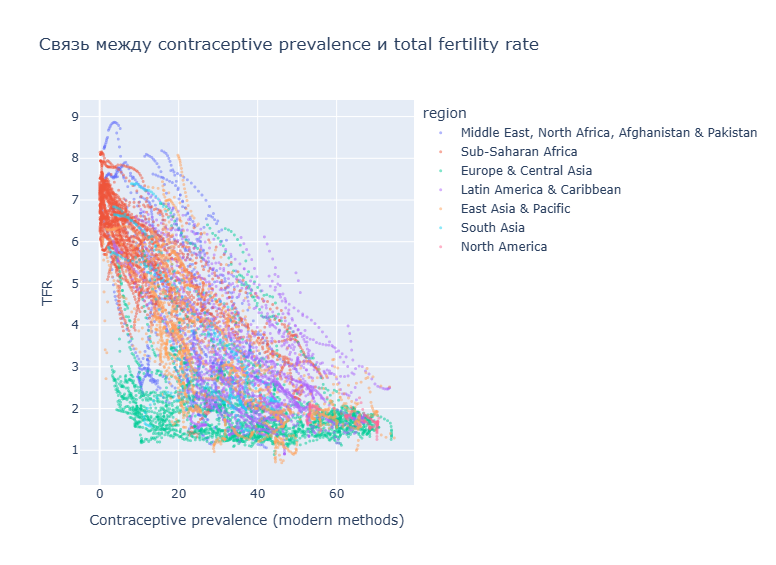

In [41]:
if {"contraceptive_prevalence_modern", "tfr", "region"}.issubset(indicator_enriched.columns):
    scatter_df = indicator_enriched.dropna(
        subset=["contraceptive_prevalence_modern", "tfr", "region"]
    ).copy()

    fig = px.scatter(
        scatter_df,
        x="contraceptive_prevalence_modern",
        y="tfr",
        color="region",
        hover_data=["country_iso3", "name", "year"] if "name" in scatter_df.columns else ["country_iso3", "year"],
        title="Связь между contraceptive prevalence и total fertility rate"
    )

    fig.update_traces(
        marker=dict(
            size=3,
            opacity=0.5,
            line=dict(width=0)
        )
    )

    fig.update_layout(
        xaxis_title="Contraceptive prevalence (modern methods)",
        yaxis_title="TFR",
        width=1000,
        height=550
    )

    fig.show()

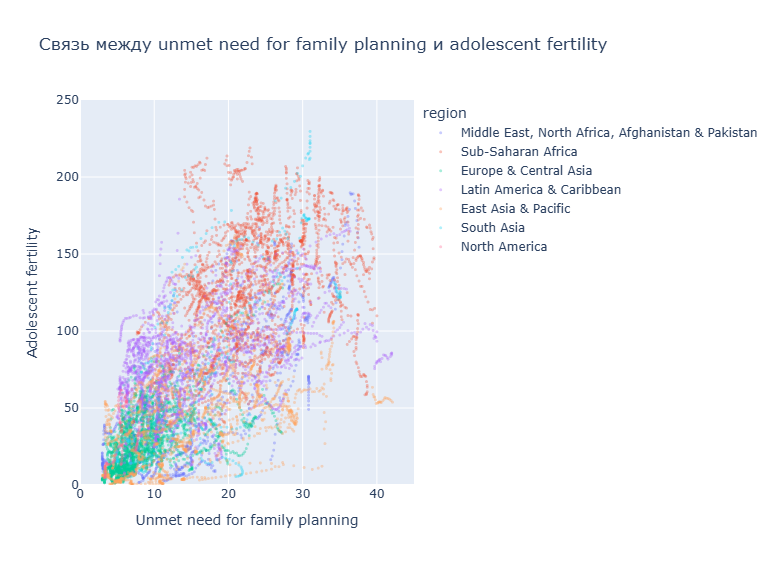

In [42]:
if {"unmet_need_family_planning", "adolescent_fertility", "region"}.issubset(indicator_enriched.columns):
    scatter_df = indicator_enriched.dropna(
        subset=["unmet_need_family_planning", "adolescent_fertility", "region"]
    ).copy()

    fig = px.scatter(
        scatter_df,
        x="unmet_need_family_planning",
        y="adolescent_fertility",
        color="region",
        hover_data=["country_iso3", "name", "year"] if "name" in scatter_df.columns else ["country_iso3", "year"],
        title="Связь между unmet need for family planning и adolescent fertility"
    )

    fig.update_traces(
        marker=dict(
            size=3,
            opacity=0.35,
            line=dict(width=0)
        )
    )

    fig.update_layout(
        xaxis_title="Unmet need for family planning",
        yaxis_title="Adolescent fertility",
        width=1000,
        height=550
    )

    fig.update_xaxes(range=[0, 45])
    fig.update_yaxes(range=[0, 250])

    fig.show()

## 22. Сохранение результатов

In [43]:
fact_project_clean.to_csv(OUTPUT_DIR / "fact_indicator_value_clean.csv", index=False)
indicator_country_year_wide.to_csv(OUTPUT_DIR / "indicator_country_year_wide_clean.csv", index=False)
duplicate_groups_project.to_csv(OUTPUT_DIR / "fact_indicator_value_duplicate_groups.csv", index=False)
conflicting_duplicate_groups_project.to_csv(OUTPUT_DIR / "fact_indicator_value_conflicting_duplicates.csv", index=False)
coverage_summary.to_csv(OUTPUT_DIR / "fact_indicator_value_clean_coverage_summary.csv", index=False)
selected_indicator_coverage.to_csv(OUTPUT_DIR / "fact_indicator_value_selected_indicator_coverage.csv", index=False)

print("Файлы сохранены в:", OUTPUT_DIR)

Файлы сохранены в: notebooks\eda_outputs


## 23. Итоговые выводы

После этого notebook у нас есть:

### Что мы узнали
1. Насколько таблица полная по ключевым полям  
2. Насколько `value` заполнен по разным индикаторам  
3. Как распределяются данные по источникам  
4. Все ли страны и индикаторы корректно матчятся в dimensions  
5. Есть ли дубликаты и conflicting duplicates  
6. Какие indicators лучше всего подходят для проекта  

### Что мы сделали
1. Привели строковые поля к аккуратному виду  
2. Проверили связь с `dim_country`  
3. Проверили связь с `dim_indicator`  
4. Оставили только country-level observations  
5. Выделили project-relevant indicators  
6. Построили clean long table  
7. Построили clean wide table  

### Почему это важно для проекта
Эта clean-версия `fact_indicator_value` станет основой для:
- соединения с `raw_in_wpp`,
- построения `atlas_country_year_clean`,
- country profiles,
- визуализаций,
- аналитики,
- будущего event-aware storytelling.